In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv(r"D:\Mental health\Student_Depression_Dataset.csv")
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [5]:
df.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

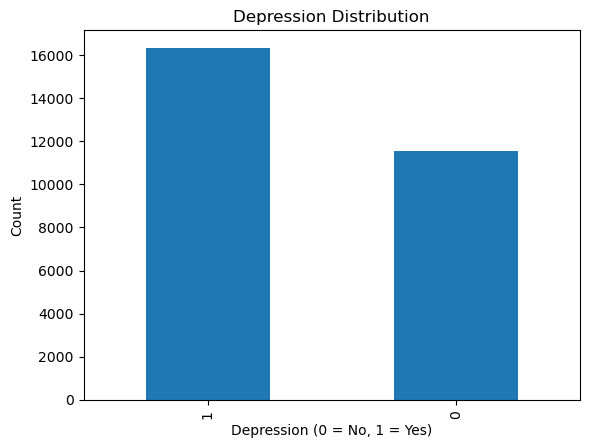

In [6]:
plt.figure()
df['Depression'].value_counts().plot(kind='bar')
plt.title("Depression Distribution")
plt.xlabel("Depression (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

<Figure size 640x480 with 0 Axes>

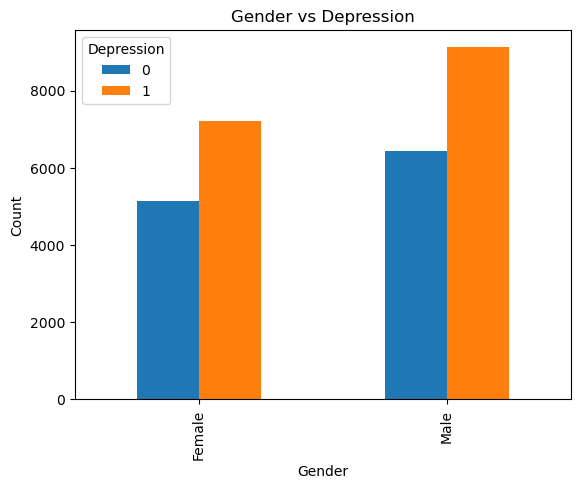

In [7]:
plt.figure()
pd.crosstab(df['Gender'], df['Depression']).plot(kind='bar')
plt.title("Gender vs Depression")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [8]:

if 'id' in df.columns:
    df = df.drop('id', axis=1)


label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

df.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,51,11,5.0,0.0,8.97,2.0,0.0,0,0,3,1,3.0,1.0,0,1
1,0,24.0,3,11,2.0,0.0,5.90,5.0,0.0,0,1,10,0,3.0,2.0,1,0
2,1,31.0,44,11,3.0,0.0,7.03,5.0,0.0,2,0,5,0,9.0,1.0,1,0
3,0,28.0,49,11,3.0,0.0,5.59,2.0,0.0,1,1,7,1,4.0,5.0,1,1
4,0,25.0,16,11,4.0,0.0,8.13,3.0,0.0,0,1,17,1,1.0,1.0,0,0


In [9]:
X = df.drop('Depression', axis=1)
y = df['Depression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [10]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf)*100)
print(classification_report(y_test, pred_rf))

Random Forest Accuracy: 82.90628919548469
              precision    recall  f1-score   support

           0       0.81      0.78      0.79      2343
           1       0.84      0.86      0.85      3238

    accuracy                           0.83      5581
   macro avg       0.83      0.82      0.82      5581
weighted avg       0.83      0.83      0.83      5581



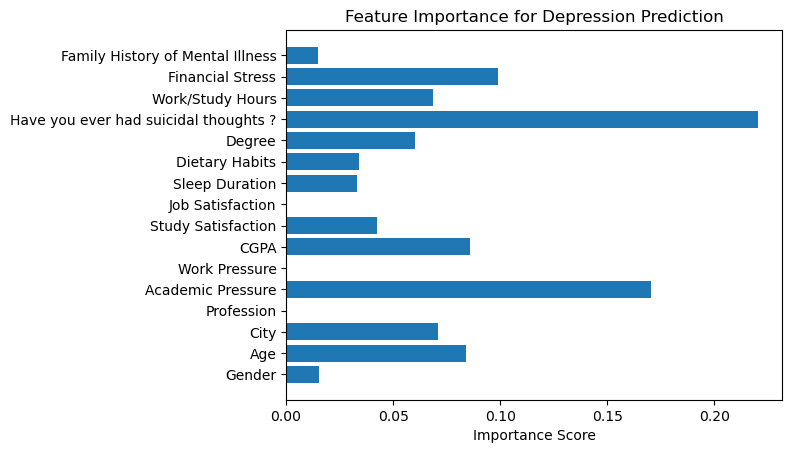

In [11]:
importance = rf.feature_importances_

plt.figure()
plt.barh(X.columns, importance)
plt.title("Feature Importance for Depression Prediction")
plt.xlabel("Importance Score")
plt.show()

In [12]:
values = []

print("Enter the details using words for categorical fields and numbers for numerical fields.\n")

for col in X.columns:
    if col in label_encoders:
        options = list(label_encoders[col].classes_)
        print(f"{col} options: {', '.join(map(str, options))}")
        while True:
            user_input = input(f"Enter {col}: ").strip()
            matches = [opt for opt in options if str(opt).lower() == user_input.lower()]
            if matches:
                encoded_value = label_encoders[col].transform([matches[0]])[0]
                values.append(encoded_value)
                break
            else:
                print(f"Invalid input for {col}. Please choose from: {', '.join(map(str, options))}")
    else:
        while True:
            user_input = input(f"Enter {col}: ").strip()
            try:
                if '.' in user_input:
                    val = float(user_input)
                else:
                    val = int(user_input)
                values.append(val)
                break
            except ValueError:
                print(f"Invalid input for {col}. Please enter a number.")

new_user = pd.DataFrame([values], columns=X.columns)
prediction = rf.predict(new_user)

if prediction[0] == 1:
    print("\nResult: Depressed")
    print("Opinion: The user may be under stress. Counseling, rest, and a healthy routine are recommended.")
else:
    print("\nResult: Not Depressed")
    print("Opinion: The user seems mentally stable. Maintain a good lifestyle and positive habits.")



Enter the details using words for categorical fields and numbers for numerical fields.

Gender options: Female, Male


Enter Gender:  female
Enter Age:  21


City options: 3.0, Agra, Ahmedabad, Bangalore, Bhavna, Bhopal, Chennai, City, Delhi, Faridabad, Gaurav, Ghaziabad, Harsh, Harsha, Hyderabad, Indore, Jaipur, Kalyan, Kanpur, Khaziabad, Kibara, Kolkata, Less Delhi, Less than 5 Kalyan, Lucknow, Ludhiana, M.Com, M.Tech, ME, Meerut, Mihir, Mira, Mumbai, Nagpur, Nalini, Nalyan, Nandini, Nashik, Patna, Pune, Rajkot, Rashi, Reyansh, Saanvi, Srinagar, Surat, Thane, Vaanya, Vadodara, Varanasi, Vasai-Virar, Visakhapatnam


Enter City:  bhopal


Profession options: Architect, Chef, Civil Engineer, Content Writer, Digital Marketer, Doctor, Educational Consultant, Entrepreneur, Lawyer, Manager, Pharmacist, Student, Teacher, UX/UI Designer


...

Have you ever had suicidal thoughts ? options: No, Yes


Enter Have you ever had suicidal thoughts ?:  no
Enter Work/Study Hours:  6
Enter Financial Stress:  0


Family History of Mental Illness options: No, Yes


Enter Family History of Mental Illness:  no



Result: Not Depressed
Opinion: The user seems mentally stable. Maintain a good lifestyle and positive habits.
